# Admission Chances using Keras

### Load libraries

In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Load data from admissions.csv 

In [92]:
df = pd.read_csv("admission.csv")

In [93]:
X = df[['Gre','Toefl','Cgpa']]
y = df['Chance'].apply(lambda v: 1 if v >= .75 else 0)

In [94]:
X.sample(10)

,Gre,Toefl,Cgpa
239,299,100,7.89
285,331,116,9.26
303,323,107,8.55
5,330,115,9.34
333,319,108,8.54
391,318,106,8.65
422,322,112,9.02
141,332,118,9.36
492,298,101,7.69
232,312,107,8.27


In [95]:
y.value_counts()

Chance
0    282
1    218
Name: count, dtype: int64

## Standardization of DataSet

In [101]:
ss = StandardScaler()

In [99]:
# Split data into train and test 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [100]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((400, 3), (100, 3), (400,), (100,))

In [102]:
# Scale Train data 
X_train_scaled = ss.fit_transform(X_train)

In [135]:
X_train_scaled[:3]

array([[1.87138145, 1.56490551, 1.40893247],
       [0.19003625, 0.43325896, 0.30852476],
       [1.69439775, 0.75658655, 1.90165233]])

In [103]:
#Scale Test data 
X_test_scaled = ss.transform(X_test)

In [116]:
# Model
model = keras.Sequential([
    keras.Input(shape=(3,)),
    keras.layers.Dense(2, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [117]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape         ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ dense_11 (Dense)             │ (None, 2)            │           8 │
├──────────────────────────────┼──────────────────────┼─────────────┤
│ dense_12 (Dense)             │ (None, 1)            │           3 │
└──────────────────────────────┴──────────────────────┴─────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

In [126]:
model.layers

[<Dense name=dense_11, built=True>, <Dense name=dense_12, built=True>]

In [121]:
model.get_weights()

[array([[-0.52377987,  0.1791166 ],
        [ 0.47275266, -0.1243033 ],
        [-0.15136495,  0.37567726]], dtype=float32),
 array([-0.11189939, -0.11740412], dtype=float32),
 array([[ 1.1492797],
        [-1.0058125]], dtype=float32),
 array([-0.04195931], dtype=float32)]

In [131]:
X_train_scaled[:3]

array([[1.87138145, 1.56490551, 1.40893247],
       [0.19003625, 0.43325896, 0.30852476],
       [1.69439775, 0.75658655, 1.90165233]])

In [122]:
model.compile(loss="binary_crossentropy",  optimizer="adam",  metrics = ['accuracy'])

In [123]:
history = model.fit(X_train_scaled, y_train, epochs = 10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3275 - loss: 0.7960
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3600 - loss: 0.7774 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3875 - loss: 0.7607 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4200 - loss: 0.7460 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4425 - loss: 0.7335 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4650 - loss: 0.7232 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4900 - loss: 0.7142 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5075 - loss: 0.7076 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5375 - loss: 0.7017 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5575 - loss: 0.6968 


In [124]:
model.get_weights()

[array([[-0.42399696,  0.07730927],
        [ 0.5736911 , -0.22187373],
        [-0.04672714,  0.2717343 ]], dtype=float32),
 array([-0.1804518 , -0.21603179], dtype=float32),
 array([[ 1.0787063],
        [-0.9318413]], dtype=float32),
 array([-0.08619606], dtype=float32)]

In [129]:
y_train_p = model.predict(X_train_scaled)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [130]:
y_train_p[:3]

array([[0.4784643 ],
       [0.4784643 ],
       [0.41774154]], dtype=float32)

In [113]:
y_p = model.predict(X_test_scaled)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/stepWARNING:tensorflow:5 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002D4DFE8B7E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


<Axes: >

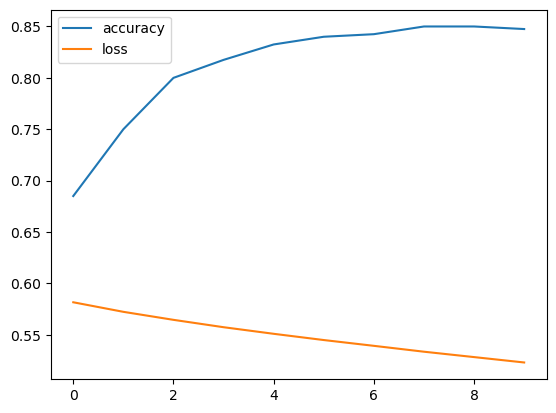

In [114]:
pd.DataFrame(history.history).plot()

In [134]:
y_p[:3]

array([[0.47087285],
       [0.8351623 ],
       [0.7139837 ]], dtype=float32)